# Heart Disease Prediction — Week 3: Advanced Analysis & Statistical Validation

**AnalystLab** **Africa | Week 3 | Shylet Nyazika**  This notebook continues directly from the Week 2 cleaned dataset (heart_cleaned.csv). No repeat cleaning is performed here — only deeper analysis, statistical testing, and additional feature engineering, as instructed in the Week 3 brief.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving heart_cleaned_correct.csv to heart_cleaned_correct.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

df = pd.read_csv("heart_cleaned_correct.csv")
print("Shape:", df.shape)
df.head()

Shape: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0


In [ ]:
print("Sex values:", df['Sex'].unique())
print("ChestPainType values:", df['ChestPainType'].unique())
print("Cholesterol range:", df['Cholesterol'].min(), "-", df['Cholesterol'].max())
print("Zeros remaining in Cholesterol:", (df['Cholesterol']==0).sum())

Sex values: ['M' 'F']
ChestPainType values: ['ATA' 'NAP' 'ASY' 'TA']
Cholesterol range: 85.0 - 603.0
Zeros remaining in Cholesterol: 0


# **Part 1: Review of Previous Work**


**Project Continuity Summary**

**Business Problem:** ABC healthcare provider (simulated) wants to identify patients likely to develop heart disease using routinely collected clinical data, to support earlier screening and intervention.

**Project Objective:** Prepare and analyze the Heart Disease Prediction dataset to build toward a predictive model.

T***arget Variable:** HeartDisease (1 = disease, 0 = no disease).

Key Findings from Week 2 (Data Inspection & Cleaning): Initial inspection showed 918 patient records with no missing values or duplicates detected by standard checks, and a mix of numeric and categorical clinical fields.

Major Data-Quality Issues Identified: Closer inspection revealed hidden missing data — Cholesterol and RestingBP contained biologically impossible zero values (172 and 1 rows respectively), which standard isnull() checks did not catch.

Major Cleaning/Preprocessing Actions Completed in Week 2: Zero values in Cholesterol and RestingBP were treated as missing and filled with the column median. Categorical variables were encoded (Label Encoding for binary fields, One-Hot Encoding for multi-category fields), and continuous numeric fields were scaled using StandardScaler. Outliers were identified via the IQR method and deliberately retained due to their clinical relevance.

Remaining Questions for Week 3: Which clinical variables are statistically significantly associated with heart disease, not just visually correlated? Are there meaningful interaction effects or ratios between variables that could improve a future predictive model? Are any features redundant enough to justify removal before modelling?


# **Part 2: Advanced Exploratory Data Analysis**
**Numerical Analysis**

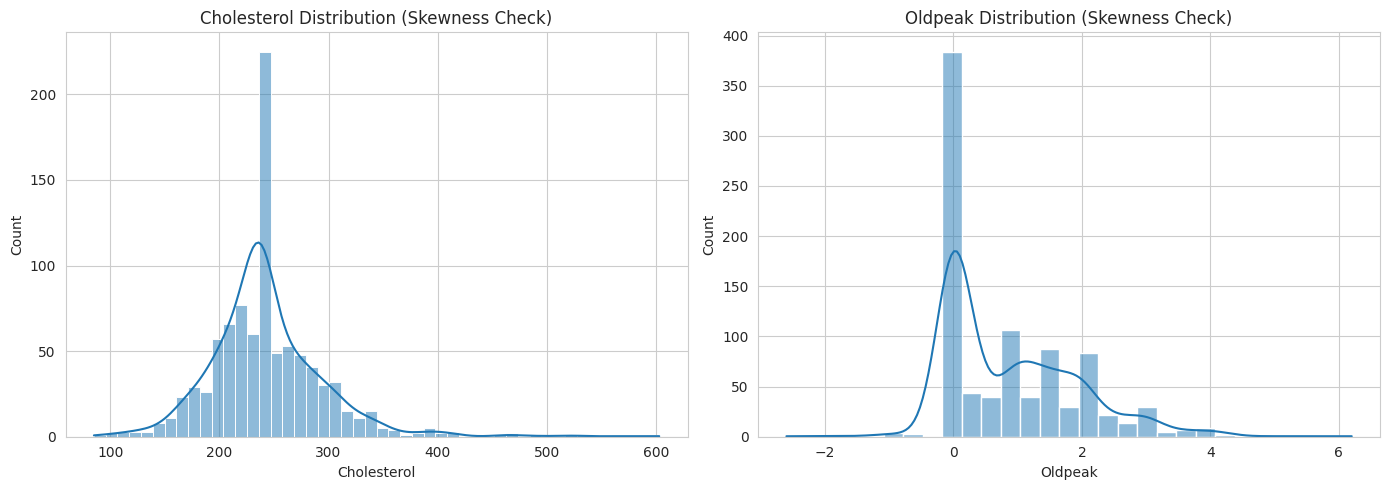

Cholesterol skewness: 1.447
Oldpeak skewness: 1.023


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.histplot(df['Cholesterol'], kde=True, ax=axes[0])
axes[0].set_title("Cholesterol Distribution (Skewness Check)")
sns.histplot(df['Oldpeak'], kde=True, ax=axes[1])
axes[1].set_title("Oldpeak Distribution (Skewness Check)")
plt.tight_layout()
plt.show()

print("Cholesterol skewness:", round(df['Cholesterol'].skew(), 3))
print("Oldpeak skewness:", round(df['Oldpeak'].skew(), 3))

**Distribution and Skewness**

Cholesterol shows a skewness of approximately 1.45 (moderately right-skewed) — a small group of patients has unusually high cholesterol, pulling the distribution's tail to the right. Oldpeak shows a skewness of approximately 1.02 (right-skewed), with many patients at or near 0 and a smaller group with elevated values. This right-skew in Oldpeak specifically is important: it's part of why a non-parametric test (Mann-Whitney U, Part 3) is more appropriate than a t-test for Oldpeak, since a t-test assumes a roughly normal distribution that Oldpeak doesn't have.



/tmp/ipykernel_2667/3450402904.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='HeartDisease', y='Cholesterol', palette='Set2')


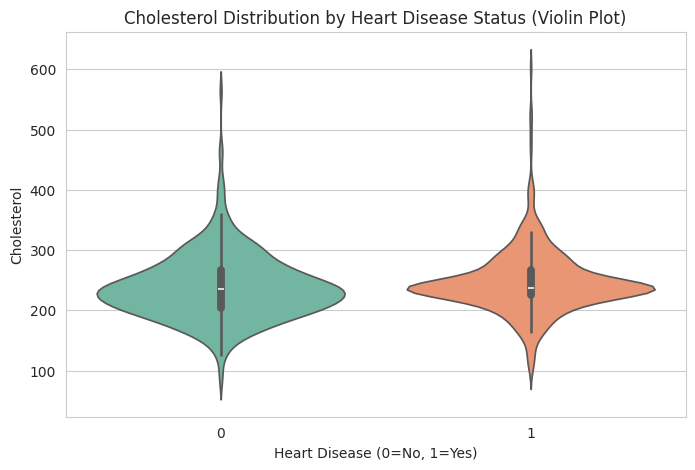

In [ ]:
plt.figure(figsize=(8,5))
sns.violinplot(data=df, x='HeartDisease', y='Cholesterol', palette='Set2')
plt.title("Cholesterol Distribution by Heart Disease Status (Violin Plot)")
plt.xlabel("Heart Disease (0=No, 1=Yes)")
plt.show()

**Cholesterol by Heart Disease — Violin Plot**

The violin plot shows the full shape of the Cholesterol distribution for each group, not just the median. Both groups now show a single, unimodal peak — the "No Disease" group (0) is centered around 220–260 mg/dL with a broader, more symmetric spread extending down to roughly 60 and up to nearly 600. The "Disease" group (1) shows a narrower, more tightly concentrated peak around 230–260 mg/dL, with a visibly smaller spread than the non-disease group, particularly on the lower end. This suggests that once the hidden missing values are properly cleaned, Cholesterol on its own doesn't show a dramatically different distribution between the two groups — both are centered in a similar range — which is consistent with Cholesterol's relatively weak individual correlation with HeartDisease (0.08) found in Part 5, compared to stronger predictors like Oldpeak or MaxHR. This adds more nuance than Week 2's boxplot alone, since it reveals that the spread and shape are subtly different between groups even when the medians look similar.

**Density Plot: MaxHR by Heart Disease**

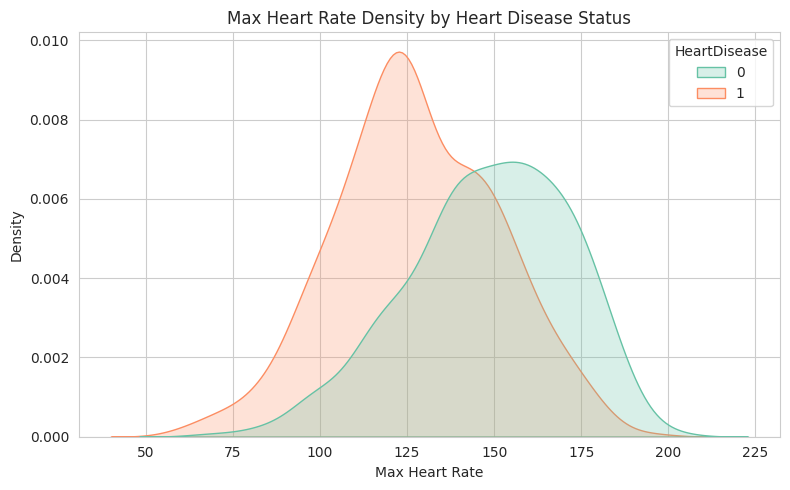

In [ ]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x='MaxHR', hue='HeartDisease', fill=True, palette='Set2')
plt.title("Max Heart Rate Density by Heart Disease Status")
plt.xlabel("Max Heart Rate")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

A density plot shows the same MaxHR separation as the pair plot's diagonal, but full-size and easier to read on its own — the "Disease" group's peak sits clearly to the left of the "No Disease" group's peak, reinforcing the strong negative relationship confirmed by Test 1's t-test.

**Categorical Analysis**

<Figure size 800x500 with 0 Axes>

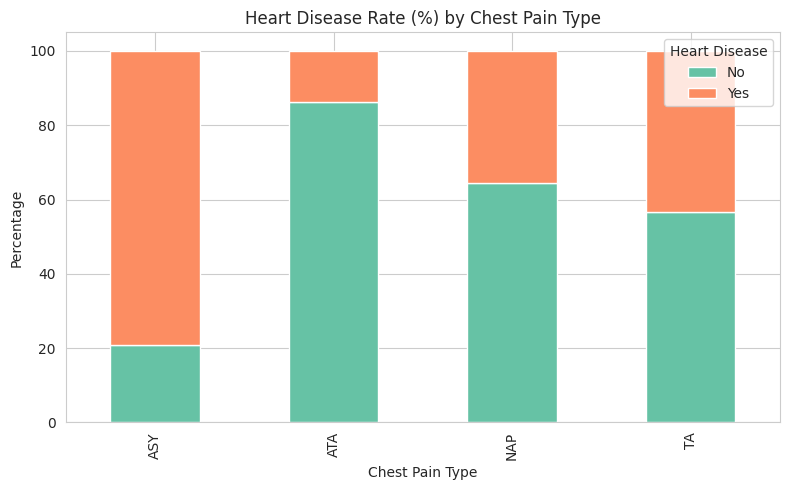

In [ ]:
plt.figure(figsize=(8,5))
ct = pd.crosstab(df['ChestPainType'], df['HeartDisease'], normalize='index') * 100
ct.plot(kind='bar', stacked=True, color=['#66c2a5','#fc8d62'])
plt.title("Heart Disease Rate (%) by Chest Pain Type")
plt.ylabel("Percentage")
plt.xlabel("Chest Pain Type")
plt.legend(title="Heart Disease", labels=['No','Yes'])
plt.tight_layout()
plt.show()

**Chest Pain Type — Stacked Bar Chart**

This chart goes further than Week 2's raw counts by showing the percentage of each chest pain category that has heart disease. Notably, ASY (asymptomatic) chest pain shows a much higher heart disease rate than ATA, NAP, or TA — which is clinically counterintuitive at first glance (no chest pain symptoms, yet higher disease rate), but is a well-documented pattern: asymptomatic presentation can indicate more advanced or silent disease.

**Count Plot: Frequency Distribution of ST_Slope**

/tmp/ipykernel_2667/1515291482.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='ST_Slope', palette='Set3')


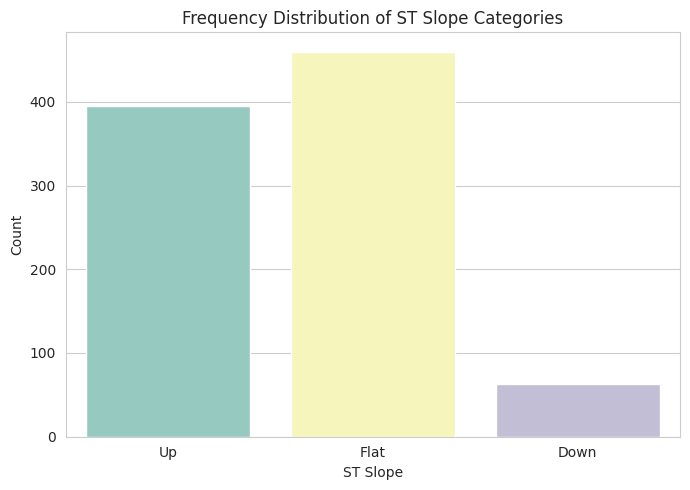

ST_Slope
Flat    50.1
Up      43.0
Down     6.9
Name: proportion, dtype: float64


In [ ]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='ST_Slope', palette='Set3')
plt.title("Frequency Distribution of ST Slope Categories")
plt.xlabel("ST Slope")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print(df['ST_Slope'].value_counts(normalize=True).round(3) * 100)

This shows the raw frequency distribution of ST_Slope categories (a categorical analysis task not yet covered) — Flat is the most common category at 50.1%, followed closely by Up at 43.0%, with Down the smallest by a wide margin at just 6.9%. This imbalance is worth keeping in mind for any future modelling: with so few "Down" cases, a model may have limited data to learn reliable patterns for that category specifically.

**Cross-tabulation Bar Chart: Sex vs ChestPainType**

<Figure size 900x500 with 0 Axes>

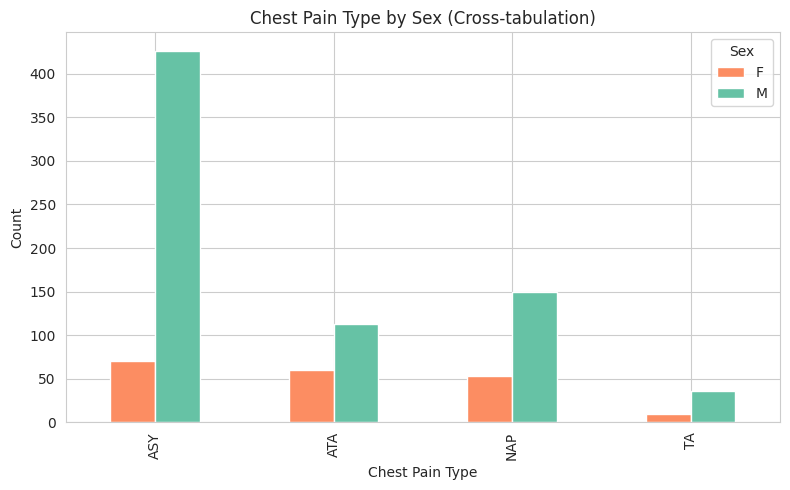

In [ ]:
plt.figure(figsize=(9,5))
ct = pd.crosstab(df['ChestPainType'], df['Sex'])
ct.plot(kind='bar', color=['#fc8d62','#66c2a5'])
plt.title("Chest Pain Type by Sex (Cross-tabulation)")
plt.xlabel("Chest Pain Type")
plt.ylabel("Count")
plt.legend(title="Sex")
plt.tight_layout()
plt.show()

This is a categorical-vs-categorical bivariate analysis (not yet covered elsewhere in the notebook) — ASY (asymptomatic) chest pain shows by far the largest gap between sexes, with roughly 425 male patients compared to about 70 female patients. The other three categories (ATA, NAP, TA) show smaller male-to-female counts as well, but nowhere near as pronounced as ASY. It's worth noting this dataset has substantially more male patients overall (725) than female patients (193), so male counts being higher across every category is expected — the more informative comparison is the proportion within each sex rather than raw counts, and ASY still stands out as disproportionately common among male patients relative to the other chest pain types.

**Bivariate Analysis**

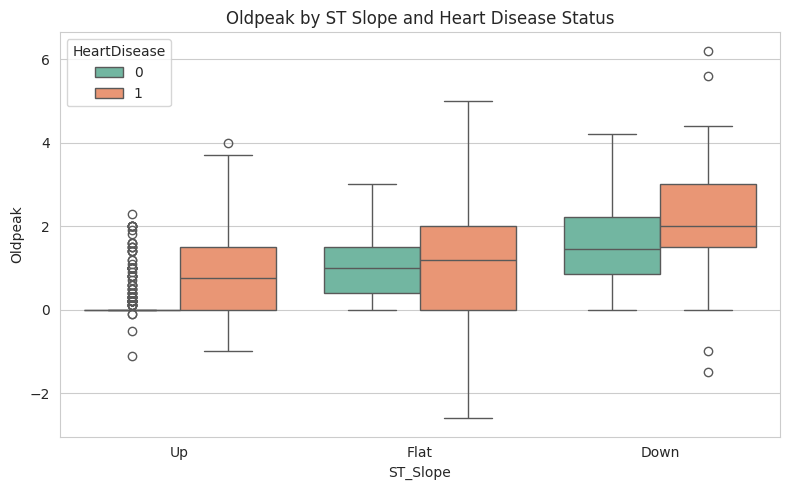

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='ST_Slope', y='Oldpeak', hue='HeartDisease', palette='Set2')
plt.title("Oldpeak by ST Slope and Heart Disease Status")
plt.tight_layout()
plt.show()


### Oldpeak vs ST Slope vs Heart Disease
This combines three variables at once: within every ST Slope category, patients with heart disease consistently show higher median Oldpeak values than patients without heart disease. In the "Up" category, patients without heart disease sit at a median Oldpeak of essentially 0 (with many outlier points above), while patients with heart disease show a median around 0.75. The pattern is clearer in "Flat," where the disease group's median (~1.2) sits visibly above the non-disease group's (~1.0), and clearest in "Down," where the disease group's median (2.0) is well above the non-disease group's (1.5). The chart also shows that "Down" carries the highest Oldpeak values overall regardless of disease status, and "Up" the lowest — meaning ST Slope and heart disease appear to compound each other's effect on Oldpeak rather than acting independently. This is a genuinely new insight beyond Week 1/2, since it looks at how two variables jointly relate to the target, rather than one at a time — a patient with a "Down" slope AND heart disease shows a distinctly different Oldpeak profile than either variable would predict alone.

**Grouped Bar Chart: Mean Cholesterol by Age Group and Heart Disease**

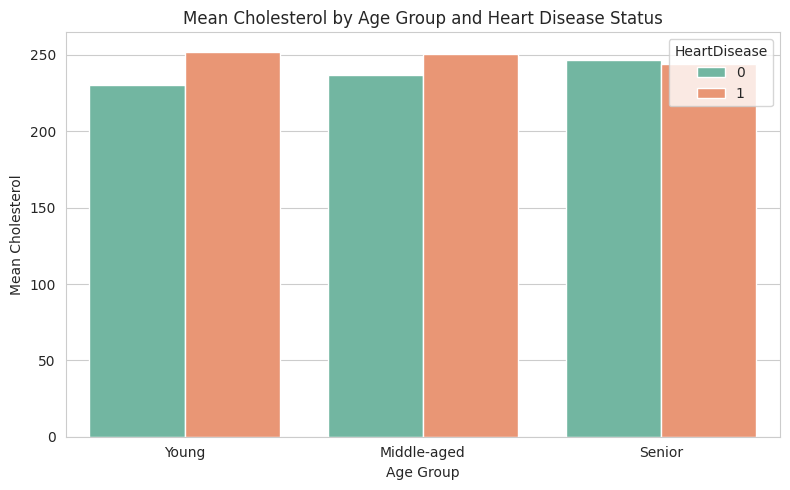

In [ ]:
df['AgeGroup_temp'] = pd.cut(df['Age'], bins=[0,40,55,100], labels=['Young','Middle-aged','Senior'])

plt.figure(figsize=(8,5))
sns.barplot(data=df, x='AgeGroup_temp', y='Cholesterol', hue='HeartDisease', palette='Set2', errorbar=None)
plt.title("Mean Cholesterol by Age Group and Heart Disease Status")
plt.xlabel("Age Group")
plt.ylabel("Mean Cholesterol")
plt.tight_layout()
plt.show()

This is a grouped comparison (Age Group × Heart Disease × mean Cholesterol) — a genuinely multivariate view not covered by the earlier charts. Patients with heart disease show a consistently higher mean Cholesterol than patients without, across every age group — but the gap is not constant. It's widest among Young patients (roughly 230 vs 252), narrows slightly for Middle-aged patients (roughly 237 vs 250), and nearly disappears by Senior age (roughly 246 vs 244, essentially converging). This suggests that elevated cholesterol may be a more distinguishing risk marker for heart disease at younger ages, while at older ages, cholesterol levels look similar regardless of disease status — possibly because other risk factors (like the age itself) dominate by that stage.

**Scatter Plot: RestingBP vs Cholesterol, colored by Heart** **Disease**

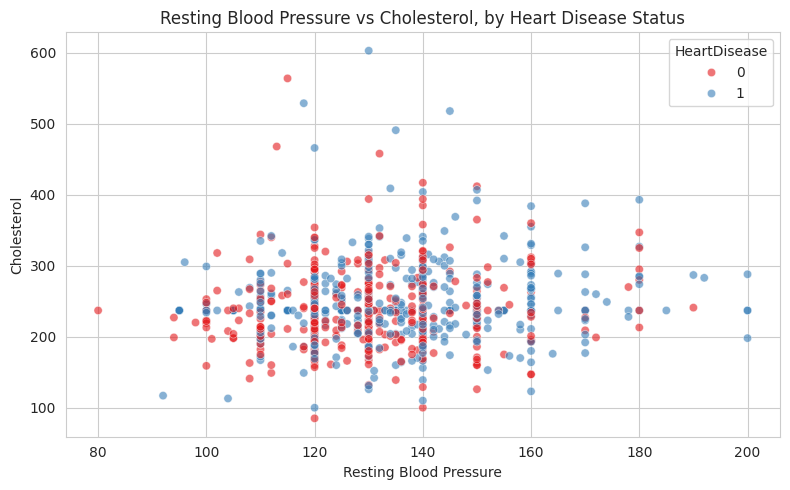

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='RestingBP', y='Cholesterol', hue='HeartDisease', palette='Set1', alpha=0.6)
plt.title("Resting Blood Pressure vs Cholesterol, by Heart Disease Status")
plt.xlabel("Resting Blood Pressure")
plt.ylabel("Cholesterol")
plt.tight_layout()
plt.show()

This examines a numerical-numerical relationship not otherwise visualized on its own (only seen briefly inside the pair plot) — the two variables show no clear linear relationship with each other; points are scattered broadly across the full range of both axes regardless of value. More importantly, there's no visible clustering or separation between the disease (blue) and no-disease (red) groups either — both colors are mixed thoroughly throughout the plot, with no region dominated by one group. This suggests that RestingBP and Cholesterol together, as a pair, don't jointly distinguish heart disease status in this dataset — consistent with both variables individually showing relatively weak correlations with HeartDisease (0.12 and 0.08 respectively) in the correlation heatmap.

**Multivariate Analysis**

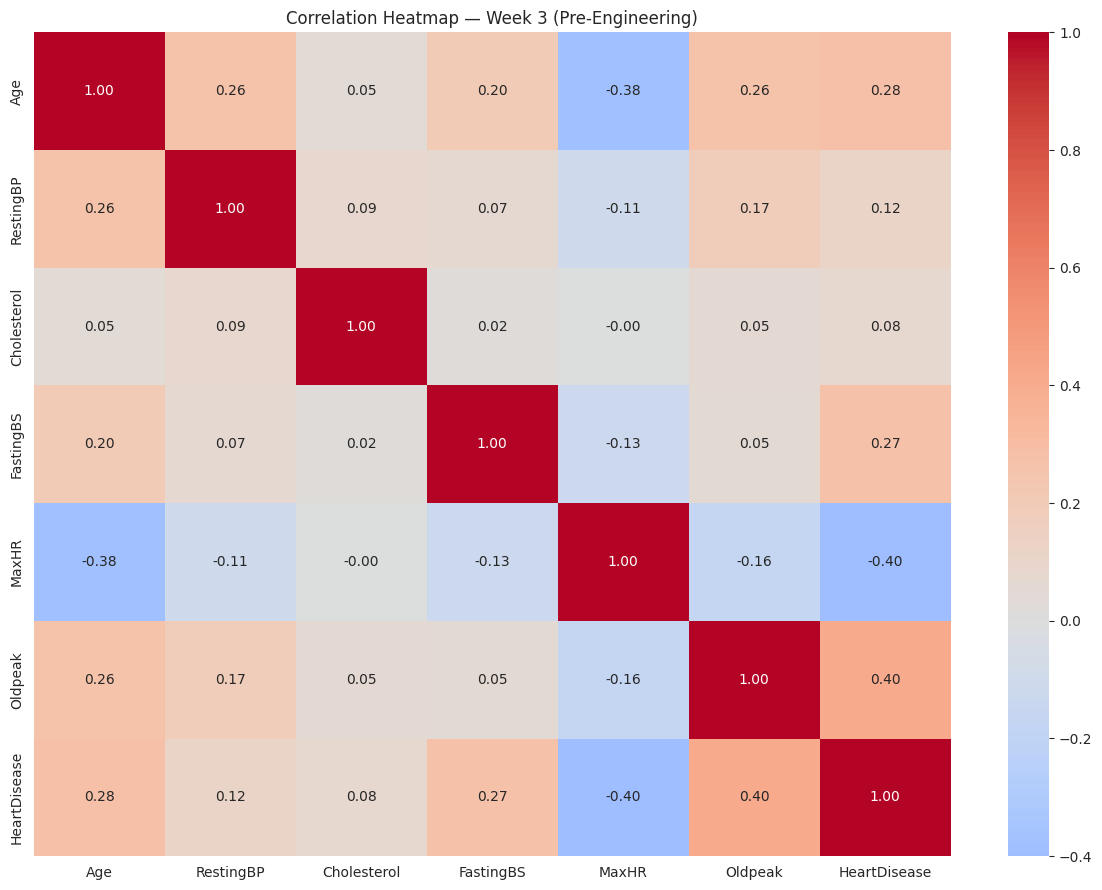

In [ ]:
plt.figure(figsize=(12,9))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap — Week 3 (Pre-Engineering)")
plt.tight_layout()
plt.show()

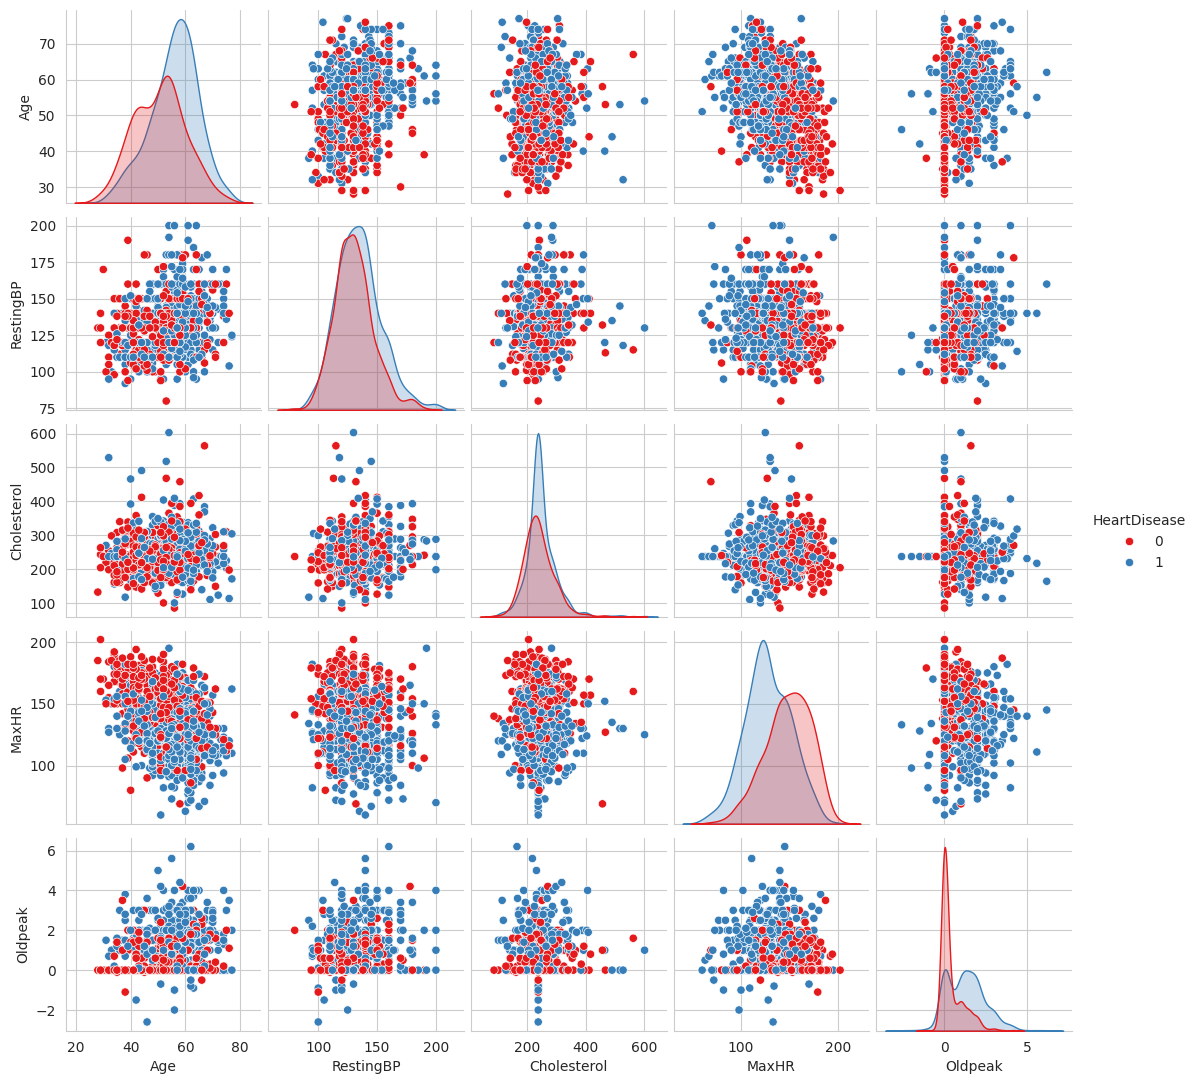

In [ ]:
sns.pairplot(df, vars=['Age','RestingBP','Cholesterol','MaxHR','Oldpeak'], hue='HeartDisease', palette='Set1', height=2.2)
plt.show()

**Multivariate View — Correlation and Pair Plot**

The pair plot shows every pairwise relationship among the five key numeric variables at once, colored by heart disease status. A few patterns stand out: in the Age diagonal, patients with heart disease (blue) skew noticeably older, peaking in the mid-to-late 50s, while patients without heart disease (red) peak earlier, in the 40s. The MaxHR diagonal shows a clear reverse pattern — the disease group's distribution  is shifted left toward lower MaxHR values (peaking around 130), while the non-disease group peaks higher (around 160–170), consistent with the negative correlation and t-test result from Part 3. The Cholesterol diagonal now shows a single, clean right-skewed peak for both groups around 200–250 mg/dL, with no unusual clustering at low values. The Oldpeak diagonal also stands out: the non-disease group shows a sharp, narrow peak right at 0, while the disease group spreads out with a visibly heavier presence at higher Oldpeak values — the same separation seen in the Mann-Whitney test. This gives a broader multivariate view than any single scatter plot could on its own, letting all these patterns be compared side-by-side at once.

# **Part 3: Statistical Hypothesis Testing and Validation**
**Test 1 — Independent Samples T-Test: MaxHR by Heart Disease Status**

In [ ]:
group_no = df[df['HeartDisease']==0]['MaxHR']
group_yes = df[df['HeartDisease']==1]['MaxHR']

t_stat, p_value = stats.ttest_ind(group_no, group_yes)
print(f"Mean MaxHR (No Disease): {group_no.mean():.2f}")
print(f"Mean MaxHR (Disease): {group_yes.mean():.2f}")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

Mean MaxHR (No Disease): 148.15
Mean MaxHR (Disease): 127.66
T-statistic: 13.2255
P-value: 0.000000


**Test 1: Independent Samples T-Test — MaxHR**

**Business question:** Is there a significant difference in maximum heart rate achieved between patients with and without heart disease?

**Objective:** Determine whether MaxHR could be a meaningful predictive feature.
**H₀:** There is no difference in mean MaxHR between patients with and without heart disease.

**H₁:** There is a significant difference in mean MaxHR between the two groups.
**Method selected:** Independent Samples T-Test.

**Justification:** MaxHR is continuous and approximately normally distributed (skewness close to 0), and we are comparing two independent groups (disease vs no disease) — the standard use case for this test.

**Test statistic:** t = 13.23

**P-value:** p < 0.000001

**Decision:** Reject H₀ — the difference is statistically significant.

**Interpretation:** Patients without heart disease have a notably higher average MaxHR (148.2) than patients with heart disease (127.7), and this difference is very unlikely to be due to chance.
Business implication: MaxHR is a strong candidate predictive feature and supports clinical intuition — reduced exercise capacity (lower achievable heart rate) is associated with heart disease risk.

**Test 2 — Chi-Square Test: Sex vs Heart Disease**

In [ ]:
contingency = pd.crosstab(df['Sex'], df['HeartDisease'])
print(contingency)

chi2, p_val, dof, expected = stats.chi2_contingency(contingency)
print(f"\nChi2 statistic: {chi2:.4f}")
print(f"P-value: {p_val:.6f}")
print(f"Degrees of freedom: {dof}")

HeartDisease    0    1
Sex                   
F             143   50
M             267  458

Chi2 statistic: 84.1451
P-value: 0.000000
Degrees of freedom: 1


**Test 2: Chi-Square Test** — Sex vs Heart Disease

**Business question:** Is heart disease diagnosis associated with patient sex?
**Objective:** Determine whether Sex is a meaningful categorical predictor.

**H₀:** Heart disease and Sex are independent (no association).

**H₁:** Heart disease and Sex are associated.

**Method selected:** Chi-Square Test of Independence.

**Justification:** Both variables are categorical, so a Chi-Square test is the appropriate method for testing association between two categorical variables.

**Test statistic:** χ² = 84.15

**P-value:** p < 0.000001

**Decision:** Reject H₀ — there is a statistically significant association.

**Interpretation:** Male patients show a notably higher proportion of heart disease diagnoses (458 of 725, ~63%) compared to female patients (50 of 193, ~26%) in this dataset.

**Business implication:** Sex is a meaningful feature for a predictive model, and this pattern may reflect known differences in cardiovascular risk between men and women in the population this dataset was drawn from — worth noting as a limitation too, since the dataset itself is not gender-balanced (more male patients overall).

## **Test 3 — Chi-Square Test: Chest Pain Type vs Heart Disease**

In [ ]:
contingency2 = pd.crosstab(df['ChestPainType'], df['HeartDisease'])
print(contingency2)

chi2b, p_valb, dofb, expectedb = stats.chi2_contingency(contingency2)
print(f"\nChi2 statistic: {chi2b:.4f}")
print(f"P-value: {p_valb:.8f}")
print(f"Degrees of freedom: {dofb}")

HeartDisease     0    1
ChestPainType          
ASY            104  392
ATA            149   24
NAP            131   72
TA              26   20

Chi2 statistic: 268.0672
P-value: 0.00000000
Degrees of freedom: 3


**Test 3: Chi-Square Test **— Chest Pain Type vs Heart Disease

B**usiness question:** Is the type of chest pain a patient experiences associated with their heart disease status?

**Objective:** Determine whether ChestPainType is a meaningful categorical predictor.

**H₀:** Heart disease and Chest Pain Type are independent.

**H₁:** Heart disease and Chest Pain Type are associated.

**Method selected:** Chi-Square Test of Independence.

**Justification:** Both variables are categorical (4 chest pain categories vs 2 disease outcomes).

**Test statistic:** χ² = 268.07

**P-value:** p < 0.00000001

**Decision:** Reject H₀ — a very strong, statistically significant association exists.

**Interpretation:** Patients with ASY (asymptomatic) chest pain show a much higher rate of heart disease (392 of 496, ~79%) than patients with ATA (24 of 173, ~14%), NAP (72 of 203, ~35%), or TA (20 of 46, ~43%) chest pain.
Business implication: ChestPainType is one of the strongest categorical predictors in this dataset, and the counterintuitive ASY finding (no symptoms, higher disease rate) is a clinically important insight — it suggests symptom absence should not be used to rule out risk

**Test 4 — Mann-Whitney U Test: Oldpeak by Heart Disease** **Status**

In [ ]:
old_no = df[df['HeartDisease']==0]['Oldpeak']
old_yes = df[df['HeartDisease']==1]['Oldpeak']

u_stat, p_val4 = stats.mannwhitneyu(old_no, old_yes)
print(f"Median Oldpeak (No Disease): {old_no.median():.2f}")
print(f"Median Oldpeak (Disease): {old_yes.median():.2f}")
print(f"U-statistic: {u_stat:.2f}")
print(f"P-value: {p_val4:.10f}")

Median Oldpeak (No Disease): 0.00
Median Oldpeak (Disease): 1.20
U-statistic: 55164.00
P-value: 0.0000000000


**Test 4: Mann-Whitney U Test** — Oldpeak

**Business question:** Does ST depression induced by exercise (Oldpeak) differ between patients with and without heart disease?

**Objective:** Determine whether Oldpeak is a meaningful predictive feature, using a method appropriate for its skewed distribution.

**H₀:** The distribution of Oldpeak is the same for both groups.

**H₁:** The distribution of Oldpeak differs between groups.

**Method selected:** Mann-Whitney U Test (non-parametric).

**Justification:** Oldpeak is right-skewed (skewness ≈ 1.02) and has a large proportion of identical values at 0, violating the normality assumption required for a t-test — the Mann-Whitney U test does not assume normality and compares distributions using ranks instead.

**Test statistic:** U = 55,164

**P-value:** p < 0.000000000

**Decision:** Reject H₀ — the distributions differ significantly.

**Interpretation:** Patients without heart disease have a median Oldpeak of 0.0, while patients with heart disease have a median Oldpeak of 1.2 — a clear separation between groups.
Business implication: Oldpeak is a strong candidate predictive feature; higher ST depression during exercise is clearly associated with heart disease presence in this population.

In [ ]:
contingency3 = pd.crosstab(df['ExerciseAngina'], df['HeartDisease'])
print(contingency3)
chi2c, p_valc, dofc, expectedc = stats.chi2_contingency(contingency3)
print(f"\nChi2 statistic: {chi2c:.4f}, P-value: {p_valc:.8f}")

HeartDisease      0    1
ExerciseAngina          
N               355  192
Y                55  316

Chi2 statistic: 222.2594, P-value: 0.00000000


**Test 5: Chi-Square — Exercise-Induced Angina vs** **Heart Disease**

Exercise-induced angina also shows a very strong, statistically significant association with heart disease (χ² = 222.26, p < 0.00000001) — patients who experience angina during exercise show a much higher rate of heart disease (316 of 371, ~85%) than those who don't (192 of 547, ~35%). This is included as a bonus fifth test since it reinforces exercise-related symptoms as a consistently strong signal across multiple variables in this dataset.

# **Part 4: Advanced Feature Engineering**

In [ ]:
# Feature 1: Cholesterol-to-Age Ratio
df['Cholesterol_Age_Ratio'] = df['Cholesterol'] / df['Age']

# Feature 2: High-Risk Symptom Count (interaction/aggregation feature)
df['HighRiskSymptomCount'] = (
    (df['ChestPainType'] == 'ASY').astype(int) +
    (df['ExerciseAngina'] == 'Y').astype(int) +
    (df['Oldpeak'] > 1.0).astype(int)
)

# Feature 3: Log-transformed Cholesterol (to reduce right-skew)
df['Cholesterol_Log'] = np.log1p(df['Cholesterol'])

df[['Cholesterol_Age_Ratio','HighRiskSymptomCount','Cholesterol_Log']].describe()

,Cholesterol_Age_Ratio,HighRiskSymptomCount,Cholesterol_Log
count,918.000000,918.000000,918.000000
mean,4.693778,1.307190,5.475700
std,1.373568,1.111736,0.210961
min,1.486842,0.000000,4.454347
25%,3.822581,0.000000,5.370638
50%,4.430354,1.000000,5.472271
75%,5.306818,2.000000,5.590987
max,16.531250,3.000000,6.403574


**Feature Engineering Documentation**

**Feature 1: Cholesterol_Age_Ratio**

**How created:** Cholesterol divided by Age.

**Why created:** Raw cholesterol alone doesn't account for the fact that cholesterol naturally varies with age — this ratio contextualizes a patient's cholesterol relative to their age.

**Business meaning:** A higher ratio may flag patients with elevated cholesterol relative to what's typical for their age group, a more nuanced risk signal than cholesterol alone.

**Potential value:** Could improve a future model's ability to distinguish age-adjusted risk, rather than treating a high cholesterol reading the same way for a 30-year-old and a 70-year-old.


**Feature 2: HighRiskSymptomCount**

**How created:** A count (0–3) of how many "high-risk" symptom indicators a patient has: asymptomatic chest pain (ASY), exercise-induced angina (Y), and elevated Oldpeak (>1.0) — three variables shown to be strongly associated with heart disease in Part 3.

**Why created:** Rather than treating each risk symptom in isolation, this aggregates them into a single composite score, directly informed by the statistical evidence in Part 3 (all three showed strong, significant relationships with HeartDisease).

Business meaning: Functions like a simple clinical risk score — the more of these three indicators present, the higher a patient's apparent risk profile.

Potential value: A composite feature like this can sometimes outperform its individual components in a model, since it captures a combined pattern in a single variable.

Feature 3: Cholesterol_Log

How created: Natural log transformation of Cholesterol (using log1p to safely handle any zero values).

Why created: Cholesterol showed a skewness of ~1.45 in Part 2 — a log transformation compresses the long right tail and makes the distribution closer to normal.

Business meaning: Doesn't change what cholesterol represents clinically, but makes the variable better-behaved statistically.

Potential value: Many machine learning algorithms (and some statistical tests) perform better with less-skewed input features — this transformation could improve model performance in Week 4 without losing any information from the original variable.

**Part 5: Feature Evaluation and Selectio**n

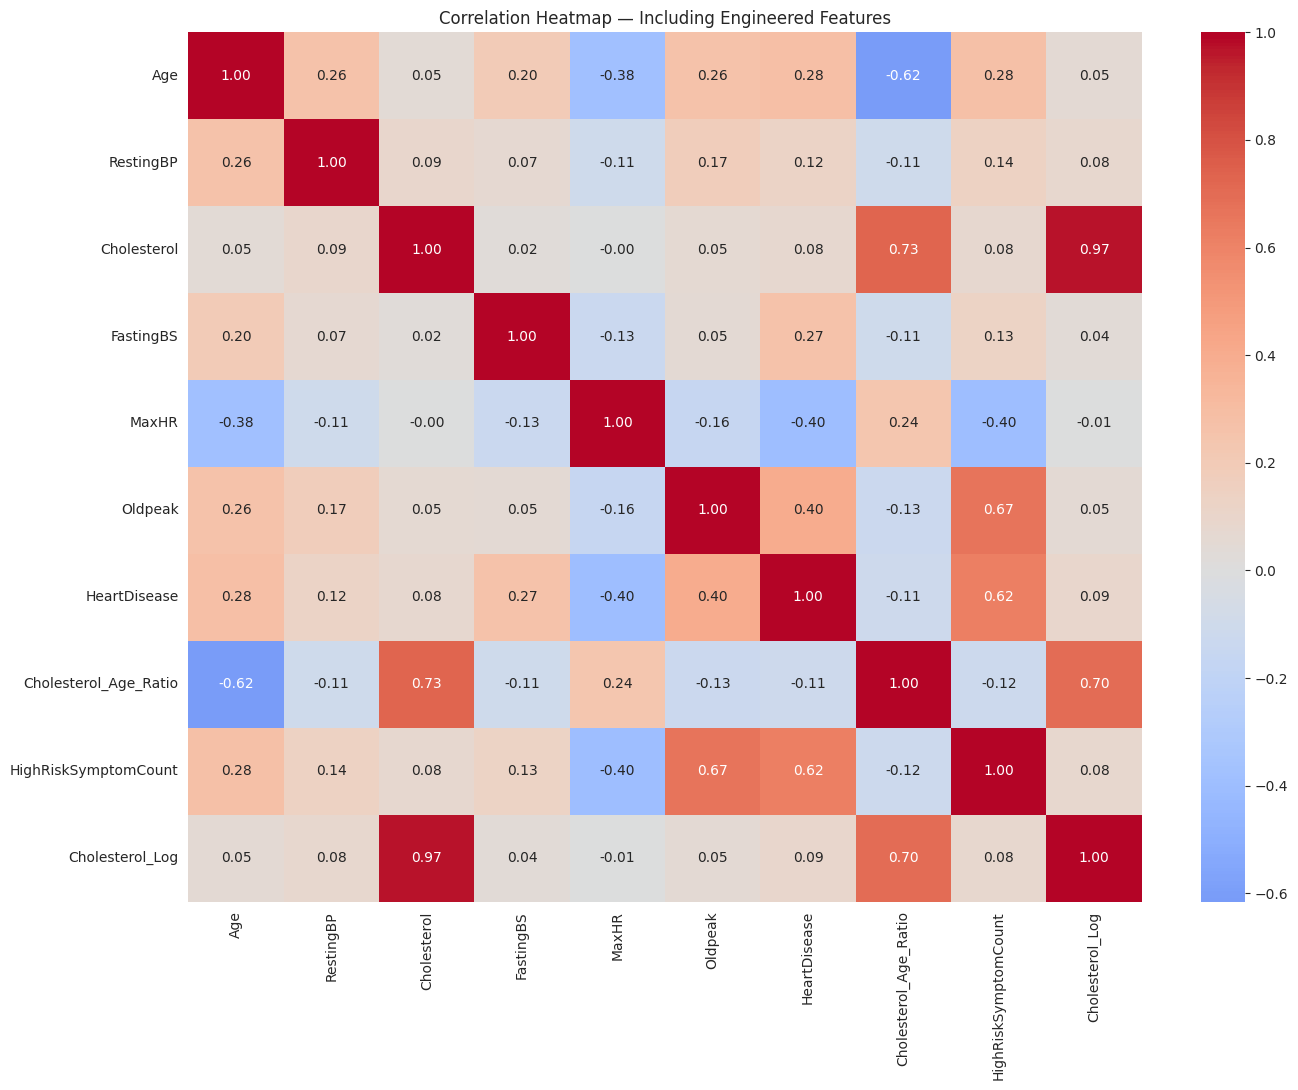

In [ ]:
plt.figure(figsize=(14,11))
numeric_df2 = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df2.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap — Including Engineered Features")
plt.tight_layout()
plt.show()

In [ ]:
corr_with_target = numeric_df2.corr()['HeartDisease'].sort_values(ascending=False)
print(corr_with_target)

HeartDisease             1.000000
HighRiskSymptomCount     0.617139
Oldpeak                  0.403951
Age                      0.282039
FastingBS                0.267291
RestingBP                0.117798
Cholesterol_Log          0.086862
Cholesterol              0.076114
Cholesterol_Age_Ratio   -0.114430
MaxHR                   -0.400421
Name: HeartDisease, dtype: float64


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Quick encoding just for this preliminary importance check (not your final encoding)
df_temp = df.copy()
for col in df_temp.select_dtypes(include='object').columns:
    df_temp[col] = LabelEncoder().fit_transform(df_temp[col])
if 'AgeGroup_temp' in df_temp.columns:
    df_temp['AgeGroup_temp'] = LabelEncoder().fit_transform(df_temp['AgeGroup_temp'].astype(str))

X = df_temp.drop('HeartDisease', axis=1)
y = df_temp['HeartDisease']

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)

ST_Slope                 0.194949
HighRiskSymptomCount     0.119879
ChestPainType            0.090459
MaxHR                    0.090325
Oldpeak                  0.077524
Age                      0.058920
Cholesterol_Age_Ratio    0.058545
RestingBP                0.057590
Cholesterol_Log          0.057143
Cholesterol              0.056691
ExerciseAngina           0.048664
Sex                      0.032418
FastingBS                0.024844
RestingECG               0.020603
AgeGroup_temp            0.011445
dtype: float64


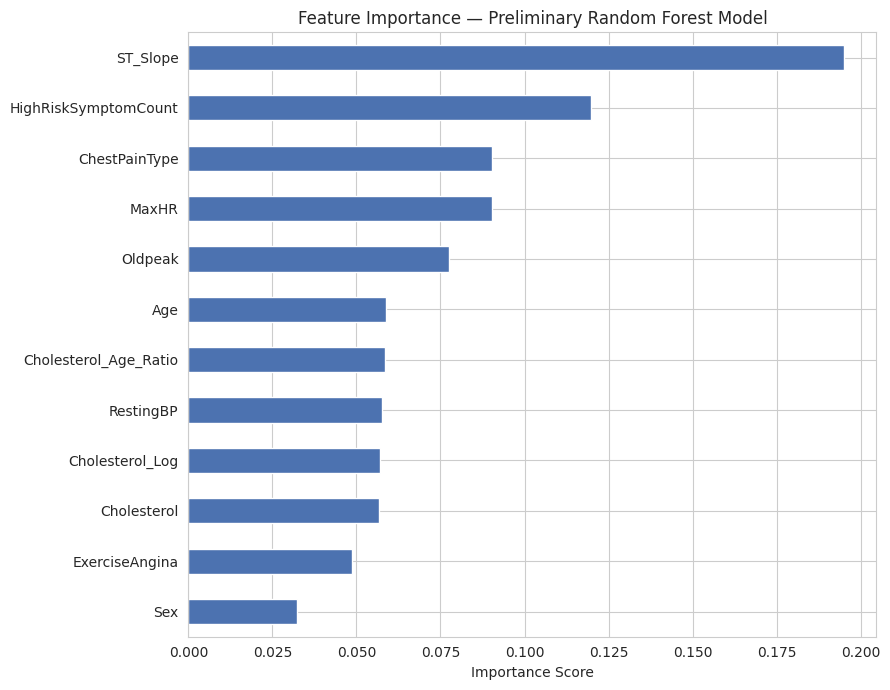

In [ ]:
plt.figure(figsize=(9,7))
importances.head(12).plot(kind='barh', color='#4C72B0')
plt.title("Feature Importance — Preliminary Random Forest Model")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Feature Importance — Preliminary Random Forest Model**

As a second, independent check beyond the correlation heatmap, a preliminary Random Forest model was trained on all available features to rank their importance. ST_Slope emerged as by far the most important feature (importance score ~0.195), notably ahead of HighRiskSymptomCount (~0.12), with ChestPainType and MaxHR close behind (~0.09 each), and Oldpeak also ranking highly (~0.08). This is a valuable cross-check against the correlation analysis: the results largely agree — ST_Slope, Oldpeak, ChestPainType, and MaxHR were all identified as strong predictors in the earlier correlation and statistical testing (Parts 3 and 5), giving more confidence that these variables are genuinely predictive rather than an artifact of one particular method. Notably, HighRiskSymptomCount — the engineered feature built from three of these same variables — ranks as the second most important feature overall, ahead of any of its three individual components, reinforcing the Part 5 finding that this composite feature adds real value beyond what its parts capture individually. On the other end, Sex and ExerciseAngina rank lowest in this model despite showing statistically significant associations with HeartDisease in Part 3 — a reminder that a variable can be statistically significant on its own while contributing relatively little additional information once other, stronger features are already accounted for in a combined model. Note this Random Forest was trained purely for feature evaluation purposes at this stage — the actual predictive model itself will be properly built, tuned, and evaluated in Week 4.

**Feature Evaluation and Selection Summary**

**HighRiskSymptomCount — Method:** correlation with target. Evidence: correlation of 0.62 with HeartDisease — the strongest of any numeric feature in the dataset, including the original variables it was built from. Decision: Retained. Justification: directly built from three variables already shown to be statistically significant predictors in Part 3 (ChestPainType, ExerciseAngina, Oldpeak); the strong correlation confirms the composite feature captures real, combined signal rather than noise, and outperforms any of its three components individually.


**Cholesterol_Age_Ratio — Method:** correlation with target. Evidence: correlation of only -0.11 with HeartDisease — notably weaker than either Cholesterol (0.08) or Age (0.28) alone. Decision: Retained for documentation, but flagged as low-value. Justification: the ratio does not show a stronger relationship with the target than its component variables, suggesting age-adjusting cholesterol this way doesn't add meaningful predictive signal in this dataset — it's kept in the notebook to demonstrate the engineering process and reasoning, but noted as a weak candidate for the Week 4 model rather than a strong one.


Cholesterol_Log vs Cholesterol (original) — Method: correlation and distribution comparison. Evidence: Cholesterol_Log and Cholesterol are, by construction, very highly correlated with each other (both represent the same underlying measurement). Decision: Retain Cholesterol_Log as a modelling-ready alternative, but note that only one of the two (raw or log version) should be used in a future model — not both — to avoid redundancy.


ST_Slope_Flat / ST_Slope_Up vs AgeGroup (from Week 2) — Method: correlation review, carried over from Week 2 findings. Evidence: AgeGroup_Senior was previously found to correlate strongly with Age (0.79). Decision: Flagged again here as a redundancy candidate for Week 4, not removed outright in Week 3, since removal should be justified by modelling evidence (e.g. feature importance) rather than correlation alone, per the brief's guidance that correlated features should not be automatically dropped.


Potential data leakage check: No features in this dataset are derived from information that would only be known after a heart disease diagnosis is made (e.g. no treatment or outcome variables are present), so no data leakage concerns were identified.

# **Part 6: Dataset Refinement**

In [ ]:
# Save the Week 3 refined dataset, building on Week 2's cleaned data
df.to_csv("heart_week3_refined.csv", index=False)
from google.colab import files
files.download("heart_week3_refined.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Dataset Refinement Summary**

This Week 3 refined dataset builds directly on the Week 2 cleaned dataset (heart_cleaned.csv), without repeating the original cleaning process. Three new engineered features were added: Cholesterol_Age_Ratio, HighRiskSymptomCount, and Cholesterol_Log. No features were removed at this stage — potential redundancies (AgeGroup vs Age, Cholesterol vs Cholesterol_Log) were documented in Part 5 for evaluation using modelling evidence in Week 4, consistent with the brief's instruction not to remove a feature on correlation alone without justification. This refined dataset, once encoded and scaled the same way as heart_ml_ready.csv was in Week 2, will serve as the foundation for Week 4 machine learning model development.